# FarmTech Solutions — visão computacional com YOLO e CNN

**Fase 6 — Colheita de Soluções Inteligentes**  
**Aluno:** Samuel Soares Carvalho Lima  
**RM:** 572084  
**Grupo:** 46

Este notebook apresenta um sistema de visão computacional para distinguir e localizar **cachorros** e **carros**. O estudo compara uma YOLO customizada em duas durações de treinamento, a YOLO padrão pré-treinada no COCO e uma CNN treinada do zero.

## 1. Objetivo e desenho experimental

O projeto foi organizado para atender às duas entregas obrigatórias:

1. criar um dataset de 80 imagens rotuladas e treinar a YOLO customizada com 30 e 60 épocas;
2. comparar a solução customizada com a YOLO padrão e com uma CNN criada do zero.

Para cada classe foram usadas **32 imagens de treino, 4 de validação e 4 de teste**. As classes foram escolhidas por serem visualmente distintas e por também existirem no COCO, permitindo uma comparação justa com uma YOLO pré-treinada.

Métricas principais:

- **mAP50 e mAP50–95:** qualidade da localização e classificação das caixas;
- **precisão e recall:** equilíbrio entre falsos positivos e objetos não detectados;
- **acurácia de classificação:** acerto da classe predominante em cada imagem;
- **tempo de treinamento e inferência:** custo computacional de cada solução.

In [1]:
# Bibliotecas, caminhos e configuração reprodutível
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 572084
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "data" / "openimages_dog_car"
RESULTS_ROOT = PROJECT_ROOT / "resultados"
MODELS_ROOT = PROJECT_ROOT / "modelos"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dataset disponível: {DATASET_ROOT.exists()}")
print(f"Resultados disponíveis: {RESULTS_ROOT.exists()}")

Projeto: C:\Users\samue\Documents\Codex\2026-09-08\eu-t\outputs\farmtech_fase6
Dataset disponível: True
Resultados disponíveis: True


## 2. Dataset, rotulagem e divisão

As imagens e as caixas delimitadoras vieram do **Open Images V7**, mantido pelo Google. As anotações oficiais foram convertidas para o formato YOLO (`classe x_centro y_centro largura altura`), que também é aceito pelo Make Sense AI.

Foram descartadas caixas marcadas como grupo, representação gráfica ou visão interna do objeto. Também se exigiu que o objeto principal ocupasse pelo menos 12% da imagem, reduzindo exemplos ambíguos. O arquivo `manifest.csv` preserva o identificador e a URL de origem de cada imagem.

A divisão é estratificada e não há repetição de imagens entre treino, validação e teste.

In [2]:
manifest = pd.read_csv(DATASET_ROOT / "manifest.csv")
distribution = pd.crosstab(manifest["class_name"], manifest["split"])
display(distribution[["train", "val", "test"]])
print(f"Total de imagens: {len(manifest)}")
display(manifest.head())

split,train,val,test
class_name,,,
car,32,4,4
dog,32,4,4


Total de imagens: 80


,image_id,class_name,class_id,split,file_name,source_url,annotation_source
0,e6d7ac64f2ae95f2,dog,0,train,dog_e6d7ac64f2ae95f2.jpg,https://open-images-dataset.s3.amazonaws.com/v...,https://storage.googleapis.com/openimages/v5/v...
1,84fbcc1b71a580d5,dog,0,train,dog_84fbcc1b71a580d5.jpg,https://open-images-dataset.s3.amazonaws.com/v...,https://storage.googleapis.com/openimages/v5/v...
2,94fff6bdd55d9279,dog,0,train,dog_94fff6bdd55d9279.jpg,https://open-images-dataset.s3.amazonaws.com/v...,https://storage.googleapis.com/openimages/v5/v...
3,59cb532b71252ece,dog,0,train,dog_59cb532b71252ece.jpg,https://open-images-dataset.s3.amazonaws.com/v...,https://storage.googleapis.com/openimages/v5/v...
4,da4e13456eb5d8a2,dog,0,train,dog_da4e13456eb5d8a2.jpg,https://open-images-dataset.s3.amazonaws.com/v...,https://storage.googleapis.com/openimages/v5/v...


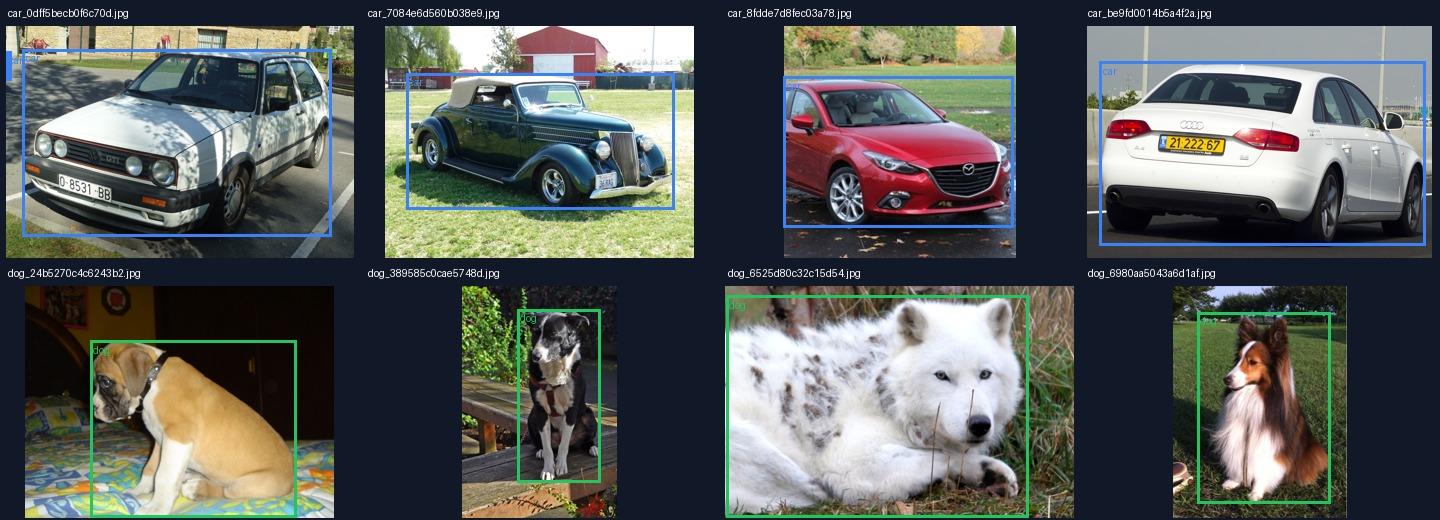

In [3]:
# Amostra do conjunto de teste com as caixas oficiais convertidas para YOLO
display(Image.open(PROJECT_ROOT / "evidencias" / "dataset_teste_rotulado.jpg"))

## 3. YOLO customizada: 30 versus 60 épocas

Os dois experimentos partiram dos mesmos pesos `yolov8n.pt`, da mesma semente e dos mesmos hiperparâmetros. A única variável alterada foi a quantidade de épocas. Isso permite atribuir diferenças de desempenho à duração do treinamento.

O modelo nano foi escolhido por combinar boa velocidade com baixo consumo de memória, característica útil para uma prova de conceito que futuramente poderia receber imagens de uma câmera embarcada.

In [4]:
# Código de reprodução do treinamento. Os resultados desta entrega já estão
# executados; altere para True somente se quiser repetir os experimentos.
RUN_TRAINING = False

if RUN_TRAINING:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "scripts/run_experiments.py", "--force"],
        check=True,
    )
else:
    print("Treinamentos preservados em resultados/ e modelos/.")
    print("Use RUN_TRAINING=True para refazer 30 e 60 épocas.")

Treinamentos preservados em resultados/ e modelos/.
Use RUN_TRAINING=True para refazer 30 e 60 épocas.


In [5]:
yolo_30 = json.loads((RESULTS_ROOT / "avaliacao_yolo_custom_30.json").read_text(encoding="utf-8"))
yolo_60 = json.loads((RESULTS_ROOT / "avaliacao_yolo_custom_60.json").read_text(encoding="utf-8"))

yolo_comparison = pd.DataFrame([
    {
        "Experimento": "YOLO customizada — 30 épocas",
        "mAP50": yolo_30["map50"],
        "mAP50-95": yolo_30["map50_95"],
        "Precisão": yolo_30["precision"],
        "Recall": yolo_30["recall"],
        "Acurácia de classe": yolo_30["classification_accuracy"],
        "Treino (s)": yolo_30["tempo_treinamento_s"],
    },
    {
        "Experimento": "YOLO customizada — 60 épocas",
        "mAP50": yolo_60["map50"],
        "mAP50-95": yolo_60["map50_95"],
        "Precisão": yolo_60["precision"],
        "Recall": yolo_60["recall"],
        "Acurácia de classe": yolo_60["classification_accuracy"],
        "Treino (s)": yolo_60["tempo_treinamento_s"],
    },
])
display(yolo_comparison.round(4))

,Experimento,mAP50,mAP50-95,Precisão,Recall,Acurácia de classe,Treino (s)
0,YOLO customizada — 30 épocas,0.8953,0.8662,0.9811,0.9,1.0,77.509
1,YOLO customizada — 60 épocas,0.8960,0.8518,0.9876,0.9,1.0,105.655


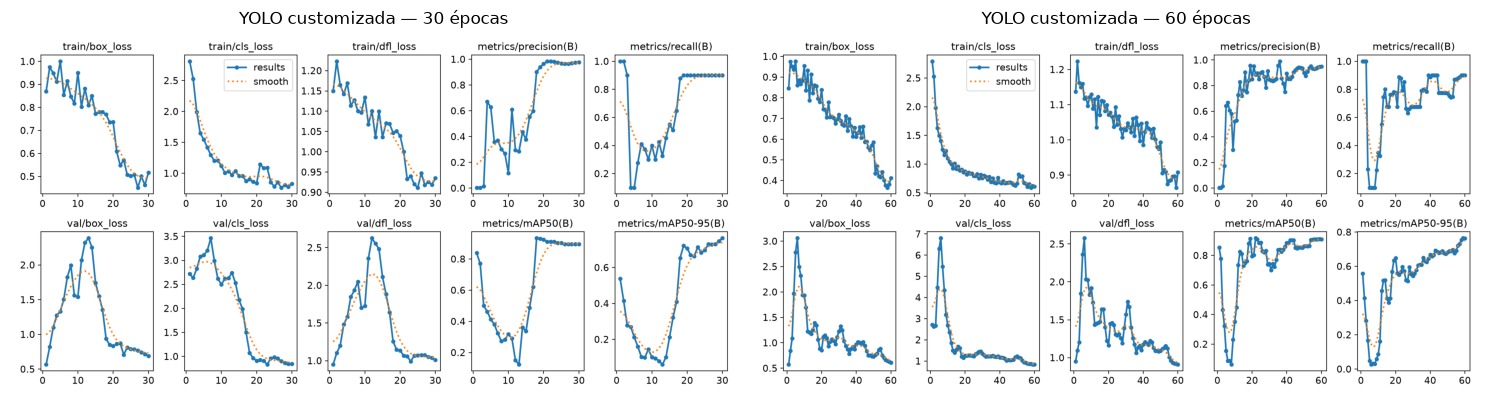

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(Image.open(RESULTS_ROOT / "treinos_yolo" / "epocas_30" / "results.png"))
axes[0].set_title("YOLO customizada — 30 épocas")
axes[0].axis("off")
axes[1].imshow(Image.open(RESULTS_ROOT / "treinos_yolo" / "epocas_60" / "results.png"))
axes[1].set_title("YOLO customizada — 60 épocas")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Análise das épocas

O experimento de **30 épocas** alcançou mAP50 de **0.895** e mAP50–95 de **0.866**, com treinamento em **77.5 segundos**. Com **60 épocas**, o mAP50 ficou em **0.896** e o mAP50–95 em **0.852**, enquanto o tempo subiu para **105.7 segundos**.

A duplicação de épocas não produziu ganho mensurável no mAP50 e apresentou pequena queda no mAP50–95. Isso indica que o modelo já havia convergido com 30 épocas e que prolongar o treinamento, neste dataset pequeno, aumenta o custo sem melhorar a generalização. Portanto, **30 épocas oferecem a melhor relação entre precisão e custo computacional**.

## 4. YOLO padrão sem customização

A YOLO padrão foi usada diretamente com os pesos treinados no COCO, sem qualquer novo treinamento. Foram mantidas apenas as classes COCO `dog` e `car`. Essa abordagem é a mais simples de integrar e serve como linha de base para medir o valor da customização.

In [7]:
yolo_standard = json.loads((RESULTS_ROOT / "avaliacao_yolo_padrao.json").read_text(encoding="utf-8"))
display(pd.DataFrame([{
    "Acurácia de classe": yolo_standard["classification_accuracy"],
    "Precisão IoU≥0,50": yolo_standard["precision_iou50"],
    "Recall IoU≥0,50": yolo_standard["recall_iou50"],
    "F1 IoU≥0,50": yolo_standard["f1_iou50"],
    "Inferência média (ms)": yolo_standard["mean_inference_ms"],
    "Tempo de novo treinamento (s)": 0,
}]).round(4))

,Acurácia de classe,"Precisão IoU≥0,50","Recall IoU≥0,50","F1 IoU≥0,50",Inferência média (ms),Tempo de novo treinamento (s)
0,0.75,1.0,0.6667,0.8,5.586,0


## 5. CNN treinada do zero

A CNN recebe imagens de 128×128 pixels e contém quatro blocos convolucionais com `BatchNorm`, `ReLU` e redução espacial, seguidos por `Global Average Pooling`, `Dropout` e uma camada linear com duas saídas. Nenhuma camada ou peso pré-treinado foi utilizado.

A CNN resolve **classificação**, não detecção: ela informa se a imagem representa cachorro ou carro, mas não devolve a posição do objeto. Essa diferença é importante ao comparar facilidade e aplicabilidade.

In [8]:
import torch
from torch import nn

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.30), nn.Linear(128, 2))

    def forward(self, inputs):
        return self.classifier(self.features(inputs))

cnn_model = SmallCNN()
total_parameters = sum(parameter.numel() for parameter in cnn_model.parameters())
print(cnn_model)
print(f"Parâmetros treináveis: {total_parameters:,}")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

,Acurácia no teste,Precisão macro,Recall macro,F1 macro,Melhor acurácia de validação,Treino (s),Inferência média (ms)
0,0.75,0.8333,0.75,0.7333,1.0,33.279,4.595


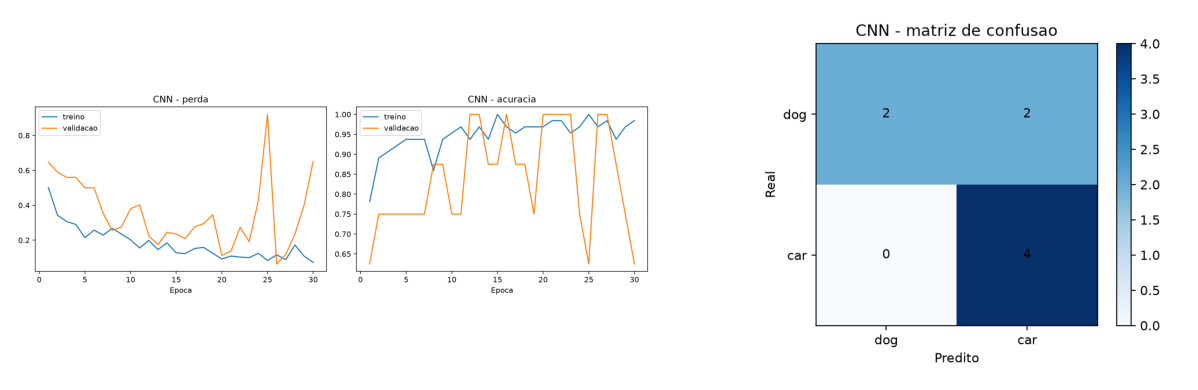

In [9]:
cnn_metrics = json.loads((RESULTS_ROOT / "metricas_cnn.json").read_text(encoding="utf-8"))
display(pd.DataFrame([{
    "Acurácia no teste": cnn_metrics["accuracy"],
    "Precisão macro": cnn_metrics["macro_precision"],
    "Recall macro": cnn_metrics["macro_recall"],
    "F1 macro": cnn_metrics["macro_f1"],
    "Melhor acurácia de validação": cnn_metrics["best_validation_accuracy"],
    "Treino (s)": cnn_metrics["tempo_treinamento_s"],
    "Inferência média (ms)": cnn_metrics["mean_inference_ms"],
}]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(Image.open(RESULTS_ROOT / "cnn_curvas_treinamento.png"))
axes[0].axis("off")
axes[1].imshow(Image.open(RESULTS_ROOT / "cnn_matriz_confusao.png"))
axes[1].axis("off")
plt.tight_layout()
plt.show()

A CNN alcançou **75.0% de acurácia** no teste e F1 macro de **0.733**. Ela reconheceu todos os carros, mas confundiu dois dos quatro cachorros. A validação chegou a 100% em algumas épocas e depois oscilou, evidenciando a alta variância causada pelo conjunto pequeno.

## 6. Comparação final das abordagens

In [10]:
comparison = json.loads((RESULTS_ROOT / "comparacao_final.json").read_text(encoding="utf-8"))["resultados"]
comparison_table = pd.DataFrame([
    {
        "Abordagem": row["abordagem"],
        "Acurácia de classe": row.get("classification_accuracy", row.get("accuracy")),
        "Precisão": row.get("precision_iou50", row.get("macro_precision", row.get("precision"))),
        "Recall": row.get("recall_iou50", row.get("macro_recall", row.get("recall"))),
        "mAP50": row.get("map50"),
        "Treino (s)": row.get("tempo_treinamento_s", 0),
        "Inferência (ms)": row.get("mean_inference_ms"),
    }
    for row in comparison
])
display(comparison_table.round(4))

,Abordagem,Acurácia de classe,Precisão,Recall,mAP50,Treino (s),Inferência (ms)
0,YOLO customizada - 30 epocas,1.00,1.0000,0.8889,0.8953,77.509,15.668
1,YOLO customizada - 60 epocas,1.00,1.0000,0.8889,0.8960,105.655,2.109
2,"YOLO padrao (COCO, sem novo treino)",0.75,1.0000,0.6667,NaN,0.000,5.586
3,CNN treinada do zero,0.75,0.8333,0.7500,NaN,33.279,4.595


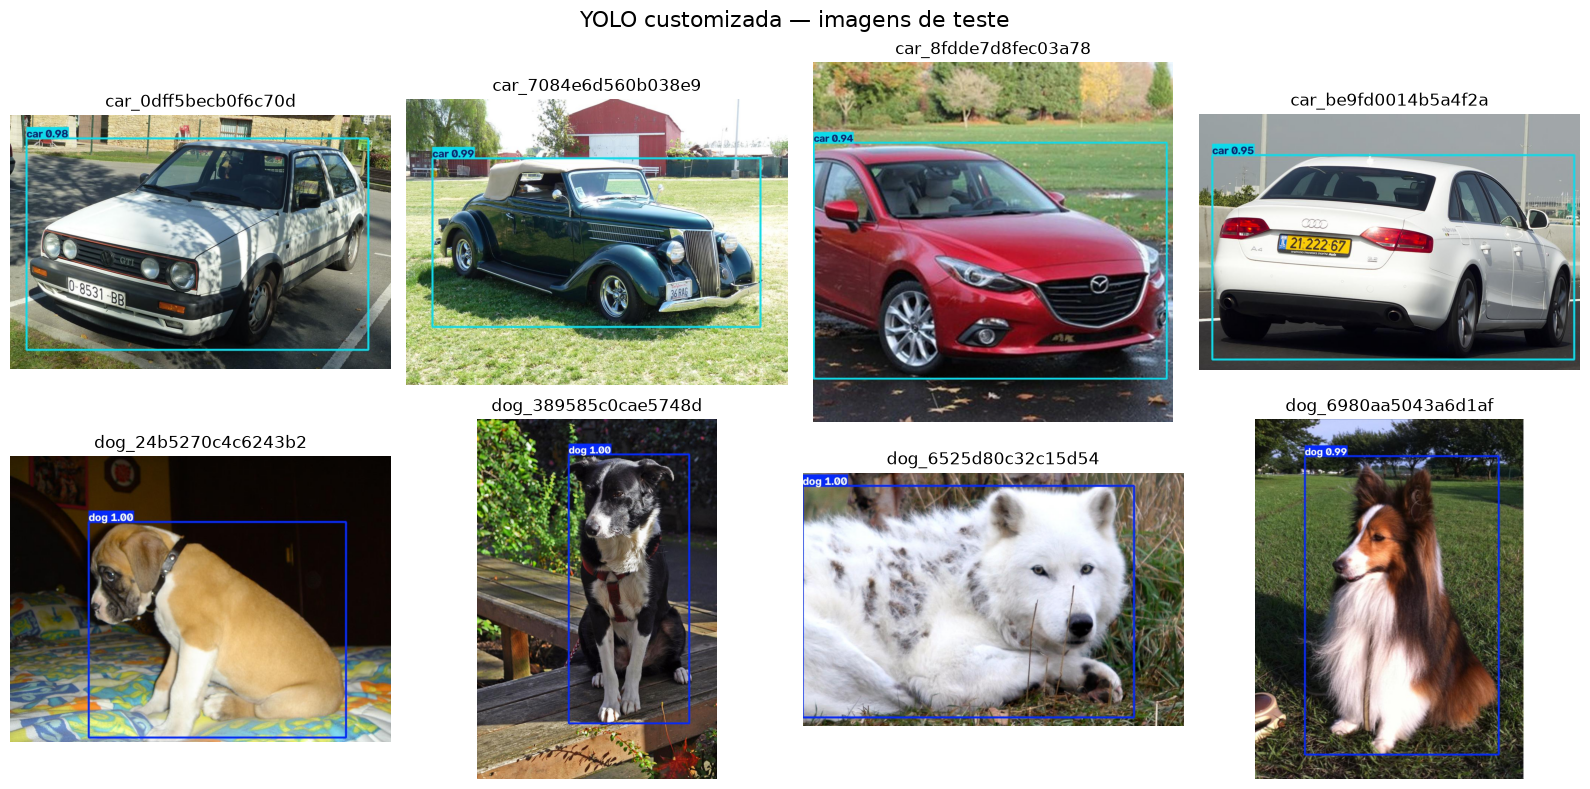

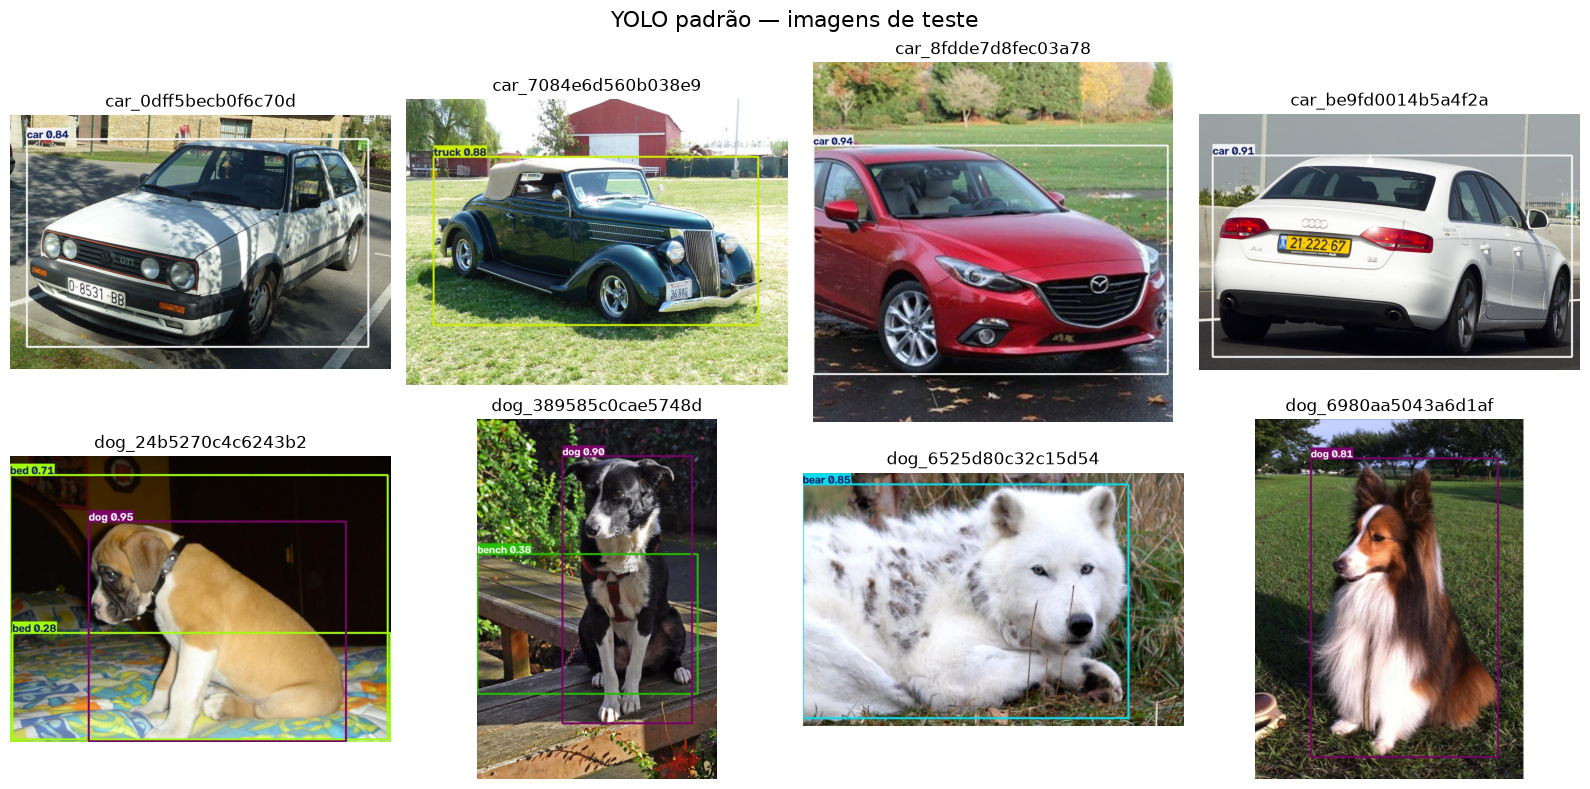

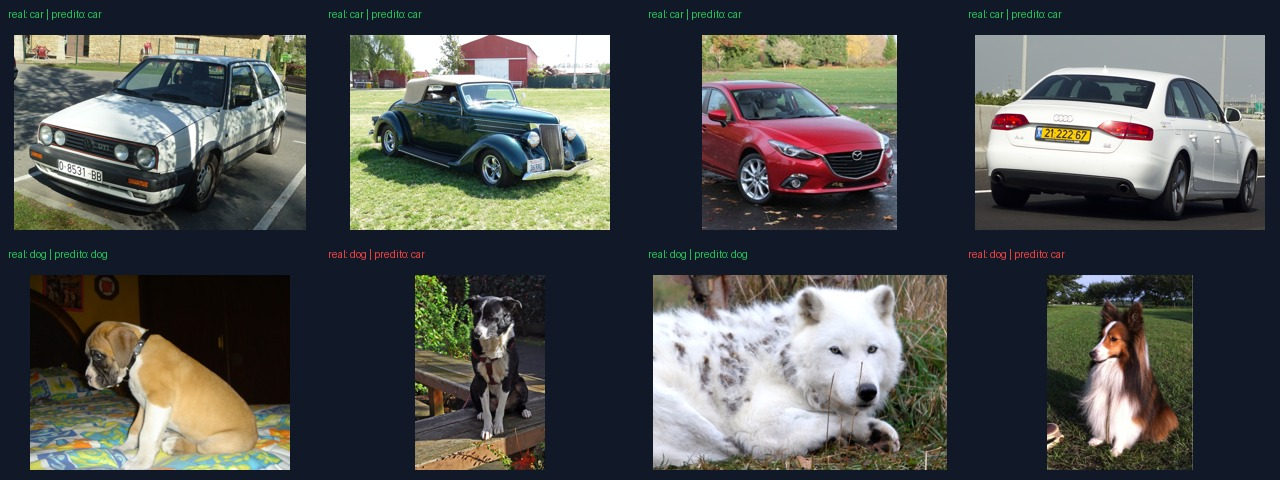

In [11]:
# Exemplos processados pelas três abordagens
def show_prediction_grid(folder, title):
    paths = sorted(Path(folder).glob("*.jpg"))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for axis, path in zip(axes.flat, paths):
        axis.imshow(Image.open(path))
        axis.set_title(path.stem[:25])
        axis.axis("off")
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_prediction_grid(RESULTS_ROOT / "predicoes_yolo_custom_30", "YOLO customizada — imagens de teste")
show_prediction_grid(RESULTS_ROOT / "predicoes_yolo_padrao", "YOLO padrão — imagens de teste")
display(Image.open(RESULTS_ROOT / "cnn_predicoes_teste.jpg"))

### Avaliação crítica

| Abordagem | Facilidade de uso e integração | Precisão e aplicabilidade | Custo |
|---|---|---|---|
| YOLO customizada — 30 épocas | Exige preparação e rotulagem, mas o pipeline fica direto após o treino | Melhor resultado: 100% de acerto de classe e mAP50 de 0.895; também localiza o objeto | 77.5s de treino |
| YOLO customizada — 60 épocas | Igual à anterior | Não superou 30 épocas; mAP50 de 0.896 | 105.7s de treino |
| YOLO padrão | Integração mais simples, sem rotulagem ou novo treino | Acurácia de 75.0%; boa linha de base, mas menos adaptada ao recorte | Sem custo de treino |
| CNN do zero | Arquitetura simples e controle total | Acurácia de 75.0%; classifica, mas não localiza objetos | 33.3s de treino |

A YOLO customizada de 30 épocas é a solução recomendada. Ela entrega a melhor combinação de localização, acerto de classe e tempo de treinamento. A YOLO padrão é útil quando velocidade de implementação importa mais que a adaptação ao domínio. A CNN demonstra aprendizado do zero, porém sofre mais com a pequena quantidade de imagens e não produz caixas delimitadoras.

## 7. Pontos fortes, limitações e riscos

**Pontos fortes**

- divisão estratificada e fixa, sem vazamento entre treino e teste;
- caixas delimitadoras humanas provenientes de um dataset reconhecido;
- comparação controlada de épocas e de três estratégias diferentes;
- pesos, métricas, curvas e predições preservados para auditoria;
- semente fixa e scripts que permitem repetir todo o processo.

**Limitações**

- somente 80 imagens e oito exemplos no teste tornam as métricas sensíveis a cada erro individual;
- imagens do Open Images possuem cenários variados e podem conter objetos secundários não rotulados nas duas classes locais;
- os tempos medidos dependem da RTX 3060 utilizada nesta execução;
- a CNN pode aprender correlações de fundo, iluminação ou enquadramento;
- o modelo é uma prova de conceito e não deve ser usado como sistema de segurança ou decisão crítica.

**Cuidados éticos e de produção**

Antes de implantação, seria necessário ampliar e diversificar a base, revisar licenças das imagens, testar falsos positivos em cenários reais, monitorar deriva e registrar incerteza. Imagens envolvendo pessoas, propriedades ou ambientes privados exigiriam consentimento e políticas de retenção.

## 8. Execução no Google Colab e Google Drive

1. faça upload deste repositório ou clone-o no Colab;
2. opcionalmente monte o Drive com `from google.colab import drive; drive.mount('/content/drive')`;
3. instale as dependências com `pip install -r requirements.txt`;
4. mantenha `RUN_TRAINING=False` para consultar os resultados já produzidos;
5. altere para `True` para repetir os treinamentos de 30 e 60 épocas.

A base já está separada nas pastas `train`, `val` e `test`, e pode ser copiada integralmente para o Google Drive sem alterar os caminhos relativos do projeto.

In [12]:
print("Resumo final")
print(f"Imagens: {len(manifest)} (64 treino, 8 validação, 8 teste)")
print(f"YOLO 30 épocas — mAP50: {yolo_30['map50']:.3f}; mAP50-95: {yolo_30['map50_95']:.3f}")
print(f"YOLO 60 épocas — mAP50: {yolo_60['map50']:.3f}; mAP50-95: {yolo_60['map50_95']:.3f}")
print(f"YOLO padrão — acurácia de classe: {yolo_standard['classification_accuracy']:.1%}")
print(f"CNN do zero — acurácia: {cnn_metrics['accuracy']:.1%}")
print("Modelo recomendado: YOLO customizada com 30 épocas.")

Resumo final
Imagens: 80 (64 treino, 8 validação, 8 teste)
YOLO 30 épocas — mAP50: 0.895; mAP50-95: 0.866
YOLO 60 épocas — mAP50: 0.896; mAP50-95: 0.852
YOLO padrão — acurácia de classe: 75.0%
CNN do zero — acurácia: 75.0%
Modelo recomendado: YOLO customizada com 30 épocas.
